# SLM Labs v2 — Thai Sign Language → open-vocabulary sign extraction → LLM → Thai → Speech

**สิ่งที่เพิ่มจาก Demo 1 (v1)** — code อยู่ใน package [`slm_labs/`](slm_labs) (notebook นี้ = ห้องทดลอง, config/architecture อยู่ใน `.py`)

```
.mp4 (ทุก fps / ทุกสถานที่) ─► MediaPipe Holistic ─► Hand/Body/Face features (T×D, normalised by shoulder)
      │
      ├─► [SSL: SignDINO-style]  student(global+local views)  ⇄  teacher(EMA, global views)      ← ใหม่ (ไม่ใช้ label)
      ▼
   SignEncoder (MLP×3 → fusion → Transformer)  ─► CTC head / cls head / emb head (128-d, L2)      ← emb head ใหม่
      │
      ├─► hand-activity segmentation (ไม่พึ่ง vocab) ─► "มีกี่คำ"                               ← ใหม่
      ├─► global view: CTC tokens + frame-emb   |   local view: forward เฉพาะ segment              ← ใหม่
      ▼
   ต่อ segment: (CTC conf ≥ τ) ∧ (cos(emb, class prototype) ≥ τ_sim) → คำที่รู้   ไม่ผ่าน → "_"     ← open-set
      │
      ├─► Qdrant (local) + embeddings/*.npz + segments.jsonl  ← เก็บ "_" พร้อม frame/เวลา/ชื่อคลิป   ← memory
      │      └─ annotate ทีหลัง → learned prototype → ครั้งหน้ารู้จักโดยไม่ retrain
      ▼
   LLM (gpt-5.6 / rule) : glosses + "_" + face cue + retrieval hints ─► ภาษาไทยธรรมชาติ (คง ___)
      ▼
   TTS (MMS-TTS-tha) : พูดเฉพาะส่วนที่รู้
```

| หัวข้อ | v1 (Demo 1) | v2 (notebook นี้) |
|---|---|---|
| representation | supervised CE/CTC เท่านั้น | + **SignDINO-style SSL** (global ↔ local view self-distillation) ก่อน fine-tune |
| คำนอก vocab | ถูก force เป็นคำใกล้เคียง หรือทิ้งเงียบ ๆ | **segment → "_" + embedding + metadata** (frame, ms, ชื่อคลิป, คำในชื่อไฟล์) |
| หน่วยความจำ | ไม่มี | **Qdrant local** + npz/jsonl ; `annotate()` → รู้จักคำใหม่ครั้งหน้า ; retrieve ให้ LLM |
| ความทนต่อกล้อง/สถานที่ | aug ตอน train | + วัดจริงด้วย *shifted-domain test* + SSL views |
| LLM | glosses → ไทย | glosses **+ blanks + hints** → ไทย (คง `___`) |
| font | default | `font/*.ttf` (TH Charmonman) เป็น global |

> รันจากบนลงล่าง — ส่วน train ใช้เวลา ~1.5 ชม. บน CPU (ตั้ง `SLM_FAST=1` เพื่อทดสอบ 1 epoch) ; ตั้ง `RETRAIN=False` เพื่อโหลด checkpoint ที่มีอยู่ใน `outputs/`

In [2]:
# !pip install "mediapipe>=0.10.14" opencv-python-headless "huggingface_hub>=0.24" \
#                 pandas numpy scikit-learn jiwer sacrebleu matplotlib tqdm openai transformers scipy

## 0. Setup (conda env: `slm_lab`)

In [3]:
import os, sys, json, time, pickle, warnings, random
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "slm_labs").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import display, Audio, Video

from slm_labs.config import cfg, DEVICE, seed_all
from slm_labs.viz import setup_thai_font, plot_timeline, render_overlay_video
FONT = setup_thai_font()                      # font/*.ttf → global ของ matplotlib
FAST = os.environ.get("SLM_FAST") == "1"      # smoke-test mode (1 epoch ทุก stage)
RETRAIN = os.environ.get("SLM_RETRAIN", "1") == "1"
if FAST: cfg.SSL_EPOCHS = cfg.EPOCHS_A = cfg.EPOCHS_B = 1
torch.set_num_threads(os.cpu_count() or 4)
print("device:", DEVICE, "| torch", torch.__version__, "| font:", FONT[0], "| FAST:", FAST, "| RETRAIN:", RETRAIN)
pd.Series({k: v for k, v in cfg.to_dict().items() if "KEY" not in k}).to_frame("value").T

device: cuda | torch 2.7.0+cu128 | font: TH Charmonman | FAST: False | RETRAIN: True


,HF_REPO,DATA_DIR,USE_EXPERT_PRIMARY,USE_EXPERT_AUGMENTED,EXPERT_MAX_PER_CLASS,TARGET_FPS,MAX_FRAMES_ISO,MAX_FRAMES_SEQ,D_MODEL,N_HEADS,...,MEMORY_DIR,QDRANT_COLLECTION,LLM_PROVIDER,LLM_MODEL,TTS_BACKEND,OPENAI_TTS_MODEL,OPENAI_TTS_VOICE,FONT_DIR,OUT_DIR,DATA_TEST_DIR
value,Namonpas/thai-sign-language-tsl51,D:\SLM-labs\SLM-Labs\data\tsl51,True,False,None,10.0,96,256,256,4,...,D:\SLM-labs\SLM-Labs\memory,sign_segments,openai,gpt-5.6,mms,gpt-4o-mini-tts,alloy,D:\SLM-labs\SLM-Labs\font,D:\SLM-labs\SLM-Labs\outputs,D:\SLM-labs\SLM-Labs\data_test


## 1. Data — TSL-51 (landmarks จาก Hugging Face) → features → splits

In [4]:
from slm_labs.data import load_all, make_loader, make_ssl_loader
from slm_labs.vocab import SIGN_CLASSES, CLASS2WORD, N_CLASSES, KNOWN_WORDS

CACHE = cfg.OUT_DIR / "items_cache.pkl"
if CACHE.exists():
    iso, sent = pickle.load(open(CACHE, "rb")); meta = None
    print("loaded cached items:", {k: len(v) for k, v in iso.items()}, {k: len(v) for k, v in sent.items()})
else:
    meta, iso, sent = load_all(); pickle.dump((iso, sent), open(CACHE, "wb"))
print("vocab:", len(KNOWN_WORDS), "words /", N_CLASSES, "classes")

loaded cached items: {'train': 1415, 'val': 82, 'test': 83} {'train': 128, 'val': 62, 'test': 62}
vocab: 50 words / 52 classes


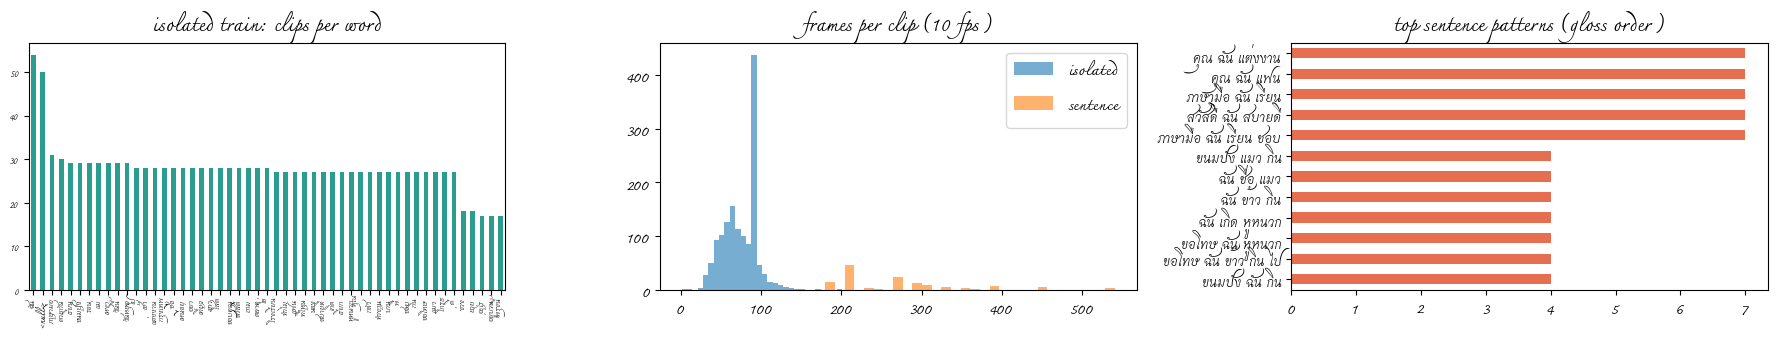

In [5]:
# EDA (font ไทย global)
fig, ax = plt.subplots(1, 3, figsize=(18, 3.6))
pd.Series([CLASS2WORD[SIGN_CLASSES[it["label"]]] for it in iso["train"]]).value_counts().plot.bar(ax=ax[0], color="#2a9d8f")
ax[0].set_title("isolated train: clips per word"); ax[0].tick_params(labelsize=8)
ax[1].hist([len(it["feat"]["hand"]) for it in iso["train"]], 30, alpha=.6, label="isolated"); ax[1].hist([len(it["feat"]["hand"]) for it in sent["train"]], 30, alpha=.6, label="sentence")
ax[1].legend(); ax[1].set_title("frames per clip (10 fps)")
pd.Series([it["pattern"] for it in sent["train"]]).value_counts().head(12).plot.barh(ax=ax[2], color="#e76f51"); ax[2].invert_yaxis(); ax[2].set_title("top sentence patterns (gloss order)")
plt.tight_layout(); plt.show()

## 2. Hand-activity segmentation (ไม่พึ่ง vocab) — "มีกี่คำ" แม้ไม่รู้จักคำ

`hand_activity()` → energy (ความเร็วมือ) + ข้อมือยกสูงกว่าระดับพัก → ช่วงที่ "กำลังทำท่า" → ตัดที่ valley ของ energy
`tune_segmentation()` grid-search ให้ #segments ≈ #glosses บน sentence-train (ไม่ใช้ label ของคำ ใช้แค่จำนวน)

best configs on sentence-train (motion-only):


,min_dist,prominence,energy_frac,min_frames,smooth,mae,bias,exact,within1
0,12,0.45,0.40,6,3,1.703125,0.859375,0.203125,0.554688
1,12,0.45,0.25,6,3,1.710938,0.867188,0.203125,0.546875
2,12,0.45,0.25,6,5,1.710938,0.648438,0.195312,0.531250
3,12,0.45,0.40,6,5,1.710938,0.648438,0.195312,0.531250
4,12,0.45,0.40,4,3,1.718750,0.875000,0.195312,0.546875


ค่าที่ใช้จริง (trade-off: signer ใน dataset ช้า/มี hold ↔ คลิปจริงเร็ว → เลือกให้ over-segment เล็กน้อย แล้วให้ CTC/embedding-merge รวมทีหลัง): {'min_frames': 6, 'min_dist': 8, 'prominence': 0.3, 'energy_frac': 0.4, 'wrist_y': 1.6, 'smooth': 3}
sentence-test motion-only  : {'mae': 2.8225806451612905, 'bias': 2.274193548387097, 'within1': 0.3225806451612903}
sentence-test best-on-train: {'mae': 1.6129032258064515, 'bias': 0.6451612903225806, 'within1': 0.5}


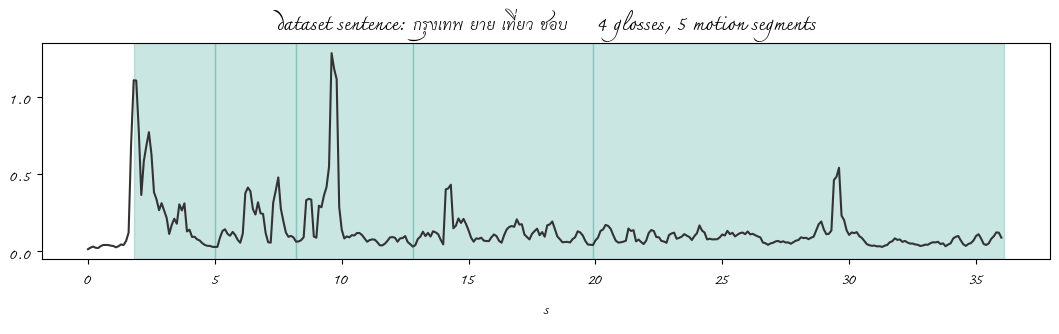

In [6]:
from slm_labs.features import hand_activity
from slm_labs.openset import segment_timeline, tune_segmentation, SEG_PARAMS

tune = tune_segmentation(sent["train"], set_global=False)
print("best configs on sentence-train (motion-only):"); display(tune.head(5))
print("ค่าที่ใช้จริง (trade-off: signer ใน dataset ช้า/มี hold ↔ คลิปจริงเร็ว → เลือกให้ over-segment เล็กน้อย แล้วให้ CTC/embedding-merge รวมทีหลัง):", SEG_PARAMS)

def seg_count_stats(items, **kw):
    d = np.array([len(segment_timeline(it["feat"], **kw)) - len(it["glosses"]) for it in items])
    return dict(mae=float(np.abs(d).mean()), bias=float(d.mean()), within1=float((np.abs(d) <= 1).mean()))
print("sentence-test motion-only  :", seg_count_stats(sent["test"]))
print("sentence-test best-on-train:", seg_count_stats(sent["test"], **{k: tune.iloc[0][k] for k in ["min_dist", "prominence", "energy_frac", "min_frames", "smooth"]}))

it = sent["test"][3]; act = hand_activity(it["feat"]); segs = segment_timeline(it["feat"], act)
plt.figure(figsize=(13, 2.8)); plt.plot(np.arange(len(act["energy"])) / 10, act["energy"], color="#333")
for s, e in segs: plt.axvspan(s / 10, e / 10, alpha=.25, color="#2a9d8f")
plt.title(f"dataset sentence: {it['pattern']}  →  {len(it['glosses'])} glosses, {len(segs)} motion segments"); plt.xlabel("s"); plt.show()

## 3. Model — Multimodal SignEncoder (+ emb head) และ SignDINO (SSL)

```
Hand ─► MLP ─┐                                                ┌─► masked-mean ─► cls head (CE)          [isolated]
Body ─► MLP ─┼─► fusion ─► +pos ─► Transformer (pre-LN) ─► x ─┼─► per-frame  ─► CTC head              [sentence]
Face ─► MLP ─┘                                                └─► masked-mean ─► emb head (128-d, L2)  [prototype / open-set / memory]

SSL (SignDINO-style): views ของคลิปเดียวกัน = 2 global (60–100% ของคลิป) + 2 local (20–45%) + spatial aug
     student(view_i) ─► DINO head ─► softmax/τ_s      teacher(EMA)(global_j) ─► centered softmax/τ_t
     loss = Σ_{i≠j} CE(teacher_j , student_i)  → local view ของ "บางคำ" ต้อง map ไปที่ representation เดียวกับ global view
```

In [7]:
from slm_labs.model import build_model, SignDINO
from slm_labs.train import train_ssl, train_stage_a, train_stage_b, save_checkpoint, load_checkpoint
from slm_labs.metrics import eval_isolated, eval_sequence, eval_isolated_shifted, openset_auroc

dl_iso_tr = make_loader(iso["train"], cfg.MAX_FRAMES_ISO, True,  False)
dl_iso_va = make_loader(iso["val"],   cfg.MAX_FRAMES_ISO, False, False)
dl_iso_te = make_loader(iso["test"],  cfg.MAX_FRAMES_ISO, False, False)
dl_seq_tr = make_loader(sent["train"], cfg.MAX_FRAMES_SEQ, True,  True, bs=16)
dl_seq_va = make_loader(sent["val"],   cfg.MAX_FRAMES_SEQ, False, True, bs=16)
dl_seq_te = make_loader(sent["test"],  cfg.MAX_FRAMES_SEQ, False, True, bs=16)
dl_ssl    = make_ssl_loader(iso["train"] + sent["train"])          # SSL ใช้ทุกคลิป ไม่ใช้ label

m = build_model(N_CLASSES, DEVICE); print(f"SignEncoder params: {sum(p.numel() for p in m.parameters())/1e6:.2f} M")
b = next(iter(dl_seq_tr))
with torch.no_grad(): o = m.forward_batch({k: v.to(DEVICE) for k, v in b.items() if torch.is_tensor(v)})
print({k: tuple(v.shape) for k, v in o.items()})
views = next(iter(dl_ssl)); print("SSL views per batch:", len(views), "| view lengths:", [tuple(v["hand"].shape) for v in views])
del m

SignEncoder params: 3.00 M
{'logits_cls': (16, 52), 'logits_ctc': (16, 256, 53), 'emb': (16, 128), 'pooled': (16, 256), 'face_emb': (16, 64), 'frame_emb': (16, 256, 256)}
SSL views per batch: 4 | view lengths: [(32, 64, 254), (32, 64, 254), (32, 45, 254), (32, 48, 254)]


## 4. Baseline **v1** (architecture เดิม: Stage A CE → Stage B CTC+CE, ไม่มี SSL)

In [8]:
seed_all(cfg.SEED); model_v1 = build_model(N_CLASSES, DEVICE); ck_v1 = cfg.OUT_DIR / "sign_encoder_v1.pt"
if RETRAIN or not ck_v1.exists():
    t0 = time.time(); histA1 = train_stage_a(model_v1, dl_iso_tr, dl_iso_va, cfg.EPOCHS_A, tag="v1_stageA")
    histB1 = train_stage_b(model_v1, dl_seq_tr, dl_seq_va, dl_iso_tr, cfg.EPOCHS_B, tag="v1_stageB")
    print(f"v1 trained in {(time.time()-t0)/60:.1f} min"); save_checkpoint(model_v1, ck_v1)
    pd.concat([histA1.assign(stage="A"), histB1.assign(stage="B")]).to_csv(cfg.OUT_DIR / "hist_v1.csv", index=False)
else:
    load_checkpoint(model_v1, ck_v1); print("loaded", ck_v1)
resA1 = eval_isolated(model_v1, dl_iso_te); resB1 = eval_sequence(model_v1, dl_seq_te); resB1_nof = eval_sequence(model_v1, dl_seq_te, use_face=False)
print(f"v1  isolated acc={resA1['acc']:.4f} F1={resA1['macro_f1']:.4f} | sentence WER={resB1['wer']:.4f} CER={resB1['cer']:.4f} sentAcc={resB1['sent_acc']:.3f} | no-face WER={resB1_nof['wer']:.4f}")

[A:v1_stageA] ep  1 loss=3.964  val acc=0.134  macroF1=0.046  (5s)
[A:v1_stageA] ep  5 loss=2.093  val acc=0.683  macroF1=0.607  (5s)
[A:v1_stageA] ep 10 loss=1.149  val acc=0.915  macroF1=0.905  (5s)
[A:v1_stageA] ep 15 loss=0.928  val acc=0.927  macroF1=0.913  (5s)
[A:v1_stageA] ep 20 loss=0.831  val acc=0.963  macroF1=0.957  (5s)
[A:v1_stageA] ep 25 loss=0.788  val acc=0.976  macroF1=0.967  (5s)
[A:v1_stageA] ep 30 loss=0.777  val acc=0.976  macroF1=0.967  (5s)
[B:v1_stageB] ep  1 ctc=238.320  val WER=26.563  CER=27.734  sentAcc=0.000  (2s)
[B:v1_stageB] ep  5 ctc=3.669  val WER=1.000  CER=1.000  sentAcc=0.000  (2s)
[B:v1_stageB] ep 10 ctc=2.671  val WER=1.000  CER=1.000  sentAcc=0.000  (2s)
[B:v1_stageB] ep 15 ctc=2.145  val WER=1.000  CER=1.000  sentAcc=0.000  (2s)
[B:v1_stageB] ep 20 ctc=1.850  val WER=0.995  CER=0.992  sentAcc=0.000  (2s)
[B:v1_stageB] ep 25 ctc=1.677  val WER=0.995  CER=0.992  sentAcc=0.000  (2s)
[B:v1_stageB] ep 30 ctc=1.656  val WER=0.995  CER=0.992  sentAcc=

## 5. **v2** = SSL (SignDINO-style) pre-train → Stage A → Stage B

[SSL] ep  1 dino_loss=6.0200  (17s)
[SSL] ep  2 dino_loss=5.9328  (16s)
[SSL] ep  3 dino_loss=5.5283  (14s)
[SSL] ep  4 dino_loss=4.7559  (13s)
[SSL] ep  5 dino_loss=3.6762  (13s)
[SSL] ep  6 dino_loss=2.7506  (13s)
[SSL] ep  7 dino_loss=2.1366  (13s)
[SSL] ep  8 dino_loss=1.7036  (15s)
[SSL] ep  9 dino_loss=1.4496  (16s)
[SSL] ep 10 dino_loss=1.2758  (15s)
SSL done in 2.4 min


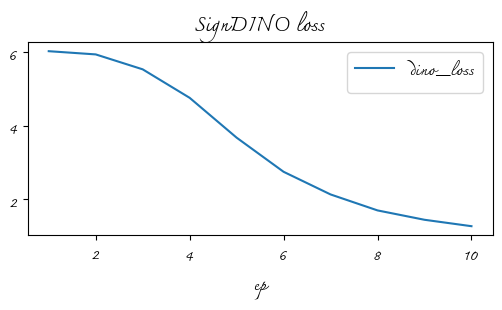

[A:v2_stageA] ep  1 loss=3.929  val acc=0.122  macroF1=0.072  (5s)
[A:v2_stageA] ep  5 loss=2.055  val acc=0.659  macroF1=0.575  (5s)
[A:v2_stageA] ep 10 loss=1.161  val acc=0.829  macroF1=0.794  (5s)
[A:v2_stageA] ep 15 loss=0.920  val acc=0.939  macroF1=0.938  (5s)
[A:v2_stageA] ep 20 loss=0.836  val acc=0.963  macroF1=0.954  (5s)
[A:v2_stageA] ep 25 loss=0.782  val acc=0.963  macroF1=0.956  (5s)
[A:v2_stageA] ep 30 loss=0.775  val acc=0.976  macroF1=0.967  (5s)
[B:v2_stageB] ep  1 ctc=237.731  val WER=29.637  CER=37.256  sentAcc=0.000  (2s)
[B:v2_stageB] ep  5 ctc=3.586  val WER=1.000  CER=1.000  sentAcc=0.000  (3s)
[B:v2_stageB] ep 10 ctc=2.547  val WER=1.000  CER=1.000  sentAcc=0.000  (3s)
[B:v2_stageB] ep 15 ctc=1.992  val WER=1.000  CER=1.000  sentAcc=0.000  (3s)
[B:v2_stageB] ep 20 ctc=1.683  val WER=1.000  CER=1.000  sentAcc=0.000  (3s)
[B:v2_stageB] ep 25 ctc=1.571  val WER=1.000  CER=1.000  sentAcc=0.000  (2s)
[B:v2_stageB] ep 30 ctc=1.530  val WER=1.000  CER=1.000  sentAcc=

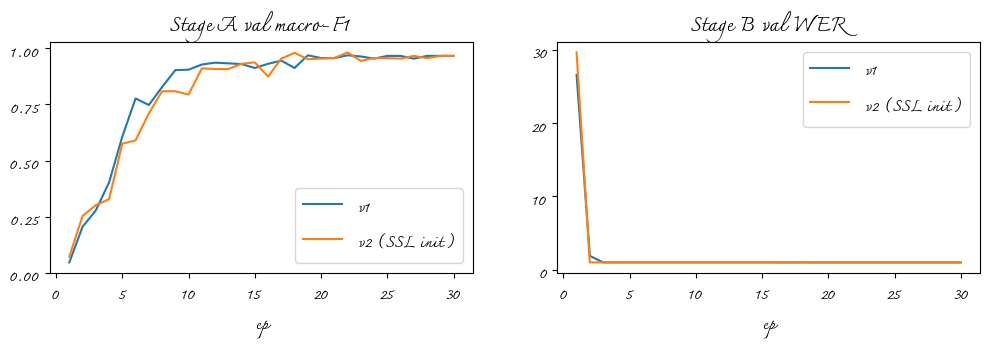

v2  isolated acc=0.3373 F1=0.2518 | sentence WER=1.0000 CER=1.0000 sentAcc=0.000 | no-face WER=1.0000
✗ ref: กรุงเทพ ฉัน เที่ยว ชอบ  | hyp: 
✗ ref: กรุงเทพ น้อง เที่ยว ชอบ  | hyp: 
✗ ref: กรุงเทพ พี่ เที่ยว ชอบ  | hyp: 
✗ ref: กรุงเทพ ยาย เที่ยว ชอบ  | hyp: 
✗ ref: กรุงเทพ แฟน เที่ยว ชอบ  | hyp: 
✗ ref: กรุงเทพ แม่ เที่ยว ชอบ  | hyp: 


In [9]:
seed_all(cfg.SEED); model_v2 = build_model(N_CLASSES, DEVICE); ck_v2 = cfg.OUT_DIR / "sign_encoder_v2.pt"
if RETRAIN or not ck_v2.exists():
    t0 = time.time(); histS = train_ssl(model_v2, dl_ssl, cfg.SSL_EPOCHS, tag="v2_ssl")
    print(f"SSL done in {(time.time()-t0)/60:.1f} min"); histS.plot(x="ep", y="dino_loss", figsize=(6, 2.5), title="SignDINO loss"); plt.show()
    t0 = time.time(); histA2 = train_stage_a(model_v2, dl_iso_tr, dl_iso_va, cfg.EPOCHS_A, tag="v2_stageA")
    histB2 = train_stage_b(model_v2, dl_seq_tr, dl_seq_va, dl_iso_tr, cfg.EPOCHS_B, tag="v2_stageB")
    print(f"v2 fine-tune done in {(time.time()-t0)/60:.1f} min"); save_checkpoint(model_v2, ck_v2)
    pd.concat([histS.assign(stage="SSL"), histA2.assign(stage="A"), histB2.assign(stage="B")]).to_csv(cfg.OUT_DIR / "hist_v2.csv", index=False)
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    histA1.plot(x="ep", y="val_f1", ax=ax[0], label="v1"); histA2.plot(x="ep", y="val_f1", ax=ax[0], label="v2 (SSL init)"); ax[0].set_title("Stage A val macro-F1")
    histB1.plot(x="ep", y="val_wer", ax=ax[1], label="v1"); histB2.plot(x="ep", y="val_wer", ax=ax[1], label="v2 (SSL init)"); ax[1].set_title("Stage B val WER"); plt.show()
else:
    load_checkpoint(model_v2, ck_v2); print("loaded", ck_v2)
resA2 = eval_isolated(model_v2, dl_iso_te); resB2 = eval_sequence(model_v2, dl_seq_te); resB2_nof = eval_sequence(model_v2, dl_seq_te, use_face=False)
print(f"v2  isolated acc={resA2['acc']:.4f} F1={resA2['macro_f1']:.4f} | sentence WER={resB2['wer']:.4f} CER={resB2['cer']:.4f} sentAcc={resB2['sent_acc']:.3f} | no-face WER={resB2_nof['wer']:.4f}")
for r, h in list(zip(resB2["refs"], resB2["hyps"]))[:6]: print(("✓" if r == h else "✗"), "ref:", " ".join(r), " | hyp:", " ".join(h))

## 6. Robustness: *shifted-domain test* (จำลอง "วิดีโอ A ถ่ายที่หนึ่ง / วิดีโอ B ถ่ายอีกที่")

ใส่ transformation ที่ไม่เคยเห็นตอน test: หมุนกล้อง / ระยะ (scale) / เลื่อนกรอบ / mirror / ความเร็ว — `strength` 1.0 = ระดับ train-aug, 1.6 = แรงกว่า train (rot ±19°, scale 0.76–1.24)

model,v1,v2 (SSL)
strength,,
0.0,0.9759,0.3373
1.0,0.9639,0.3253
1.6,0.9639,0.4096
2.2,0.9157,0.3976


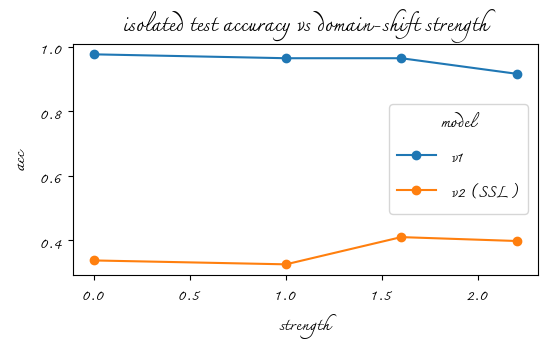

In [10]:
rows = []
for name, mdl in [("v1", model_v1), ("v2 (SSL)", model_v2)]:
    for st in [0.0, 1.0, 1.6, 2.2]:
        r = eval_isolated_shifted(mdl, iso["test"], strength=st, seed=cfg.SEED); rows.append(dict(model=name, strength=st, acc=r["acc"], macro_f1=r["macro_f1"]))
shift = pd.DataFrame(rows).pivot(index="strength", columns="model", values="acc"); display(shift.round(4))
shift.plot(marker="o", figsize=(6, 3), title="isolated test accuracy vs domain-shift strength"); plt.ylabel("acc"); plt.show()

## 7. Prototypes + open-set calibration (รู้ว่า "ไม่รู้")

- class prototype = mean ของ emb (isolated-train) ต่อ class ; `τ_sim` = 5th-percentile ของ cosine(correct class) บน val
- **known vs unknown**: known = isolated-test ; pseudo-unknown = คลิปเดิมเล่นย้อนกลับ (`time_reverse`) + segment ของคำนอก vocab จากคลิปจริง (ส่วน 9)
- score = max cosine กับ prototype (ยกเว้น null) → AUROC / TNR@95%TPR

v1 τ_sim=0.821 {'val_correct_sim_mean': 0.9118914008140564, 'val_correct_sim_std': 0.06276404857635498, 'val_nn_acc': 0.9512195121951219, 'val_max_sim_mean': 0.9193833470344543, 'val_cls_conf_mean': 0.685627281665802, 'n_train': 1415, 'n_val': 82}
v2 τ_sim=0.830 {'val_correct_sim_mean': 0.9544712901115417, 'val_correct_sim_std': 0.05196758359670639, 'val_nn_acc': 0.926829268292683, 'val_max_sim_mean': 0.9590775966644287, 'val_cls_conf_mean': 0.31600093841552734, 'n_train': 1415, 'n_val': 82}


,model,auroc,tnr_at_95tpr,thr,known_mean,unknown_mean
0,v1,0.5622,0.0843,0.8149,0.9172,0.9057
1,v2,0.5007,0.0602,0.8956,0.9588,0.9601


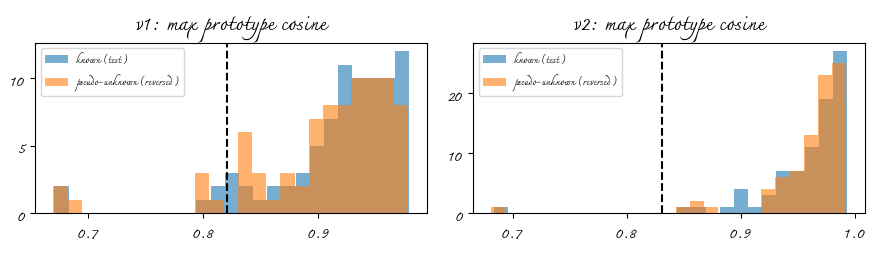

In [11]:
from slm_labs.openset import Prototypes, known_unknown_scores, analyze_clip, eval_segment_count
from slm_labs.features import time_reverse
from slm_labs.llm import set_face_baseline

protos = {}
for name, mdl in [("v1", model_v1), ("v2", model_v2)]:
    protos[name] = Prototypes.build(mdl, iso["train"], iso["val"]); print(name, "τ_sim=%.3f" % protos[name].sim_thr, protos[name].stats)
protos["v2"].save(cfg.OUT_DIR / "prototypes.npz"); protos["v1"].save(cfg.OUT_DIR / "prototypes_v1.npz")
set_face_baseline(iso["train"], cfg.OUT_DIR / "face_baseline.npz")

unknown_feats = [time_reverse(it["feat"]) for it in iso["test"]]
os_rows = []
for name, mdl in [("v1", model_v1), ("v2", model_v2)]:
    ks, us = known_unknown_scores(mdl, protos[name], iso["test"], unknown_feats)
    r = openset_auroc(ks, us); os_rows.append(dict(model=name, **r, known_mean=ks.mean(), unknown_mean=us.mean()))
openset_df = pd.DataFrame(os_rows).round(4); display(openset_df)
plt.figure(figsize=(9, 2.8))
for i, (name, mdl) in enumerate([("v1", model_v1), ("v2", model_v2)]):
    ks, us = known_unknown_scores(mdl, protos[name], iso["test"], unknown_feats)
    plt.subplot(1, 2, i + 1); plt.hist(ks, 25, alpha=.6, label="known (test)"); plt.hist(us, 25, alpha=.6, label="pseudo-unknown (reversed)"); plt.axvline(protos[name].sim_thr, color="k", ls="--"); plt.title(f"{name}: max prototype cosine"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Segment-count กับ dataset sentences: motion-only vs. model-assisted (CTC assignment + embedding merge + null filter)

,method,mae,bias,exact,within1
0,motion-only,2.823,2.274,0.081,0.323
1,model-assisted (v1),2.581,1.839,0.065,0.339
2,model-assisted (v2),2.419,1.677,0.081,0.355


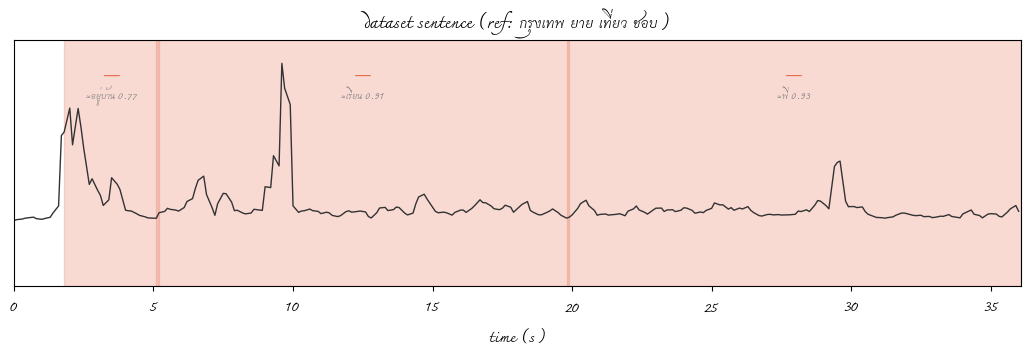

In [12]:
seg_rows = [dict(method="motion-only", **{k: v for k, v in eval_segment_count(model_v2, protos["v2"], sent["test"], use_model=False).items() if k != "rows"})]
for name, mdl in [("v1", model_v1), ("v2", model_v2)]:
    seg_rows.append(dict(method=f"model-assisted ({name})", **{k: v for k, v in eval_segment_count(mdl, protos[name], sent["test"]).items() if k != "rows"}))
seg_df = pd.DataFrame(seg_rows).round(3); display(seg_df)
# ตัวอย่าง timeline บน dataset sentence ด้วย v2
it = sent["test"][3]; a = analyze_clip(model_v2, it["feat"], protos["v2"])
plot_timeline(a, f"dataset sentence (ref: {it['pattern']})"); plt.show()

## 9. วิดีโอจริง `data_test/*.mp4` — MediaPipe → open-set extraction → memory → LLM → TTS

- ชื่อไฟล์ = ประโยคที่ user annotate ไว้ (ไม่ใช่ ground-truth ของ segment) → เก็บเป็น `candidate_sentence` / `known_hits_in_name` ใน metadata
- `EXPECTED` = gloss ที่คาดว่าจะ extract ได้ (คำใน vocab / `_` = นอก vocab) ใช้คำนวณ known-recall / WER

In [13]:
from slm_labs.extractor import HolisticExtractor, check_video_quality, extract_cached
from slm_labs.memory import SignMemory
from slm_labs.pipeline import SLMPipeline
from slm_labs.openset import slots_to_words
from slm_labs.metrics import ctc_decode_with_confidence
from slm_labs.vocab import ids_to_words, UNK
from slm_labs.features import load_landmarks, make_features
from slm_labs.data import pad_feats
from slm_labs.config import to_dev

EXPECTED = {"ไปทานข้าวด้วยกันมั้ย": ["ไป", "_", "ข้าว", "ด้วยกัน", "_"],     # ทาน (≈กิน), มั้ย นอก vocab
            "ฉันปลอบเพื่อนร้องไห้": ["ฉัน", "_", "_", "_"]}                    # ปลอบ เพื่อน ร้องไห้ นอก vocab
VIDEOS = sorted(cfg.DATA_TEST_DIR.glob("*.mp4")); print([v.name for v in VIDEOS])

extractor = HolisticExtractor()
qual = []
for v in VIDEOS:
    df = extract_cached(extractor, v); q = check_video_quality(df, verbose=False)
    qual.append(dict(clip=v.stem, src_fps=df.attrs.get("src_fps"), frames_10fps=len(df), **{k: round(q[k], 2) for k in ["pose", "face", "lh", "rh", "shoulder_width"]}, warnings=q["warnings"]))
display(pd.DataFrame(qual))

['ฉันปลอบเพื่อนร้องไห้.mp4', 'ไปทานข้าวด้วยกันมั้ย.mp4']
MediaPipe backend: Tasks HolisticLandmarker


,clip,src_fps,frames_10fps,pose,face,lh,rh,shoulder_width,warnings
0,ฉันปลอบเพื่อนร้องไห้,None,103,1.0,1.0,0.75,0.90,0.21,[]
1,ไปทานข้าวด้วยกันมั้ย,None,67,1.0,1.0,1.00,0.94,0.22,[]


qdrant unavailable → numpy fallback: ModuleNotFoundError No module named 'qdrant_client'
memory backend: numpy | segments stored so far: 0


[v1 legacy] ฉันปลอบเพื่อนร้องไห้: words=[]  all CTC tokens=[]
quality: frames=103 pose=1.00 face=1.00 LH=0.75 RH=0.90 shoulderW=0.21
  ✓ input OK

=== ฉันปลอบเพื่อนร้องไห้ ===
  SIGNS : _ _ _ _
    [0]  1.70- 3.40s  _        unknown  src=none   conf=0.00 sim=0.95  nearest=[('ทำงาน', 0.953), ('วันนี้', 0.95)]
    [1]  3.40- 4.90s  _        unknown  src=none   conf=0.00 sim=0.96  nearest=[('สวัสดี', 0.956), ('ตลาด', 0.952)]
    [2]  4.90- 6.80s  _        unknown  src=none   conf=0.00 sim=0.94  nearest=[('ตลาด', 0.942), ('กิน', 0.935)]
    [3]  6.80- 9.30s  _        unknown  src=none   conf=0.00 sim=0.96  nearest=[('โรงเรียน', 0.957), ('ตลาด', 0.937)]
  FACE  : eyebrows raised (question-like / emphasis)
  THAI  : ___ ___ ___ ___ (none)
  file-name annotation: ฉันปลอบเพื่อนร้องไห้ | known in name: ['ฉัน'] | hints: {}
  memory: stored 4 segments | latency: {'1_mediapipe_s': 0.02, '2_extract_s': 0.03, '3_llm_s': 0.0, '4_tts_s': 0.0, 'total_s': 0.05}
  WER=0.250 known-recall=0.00


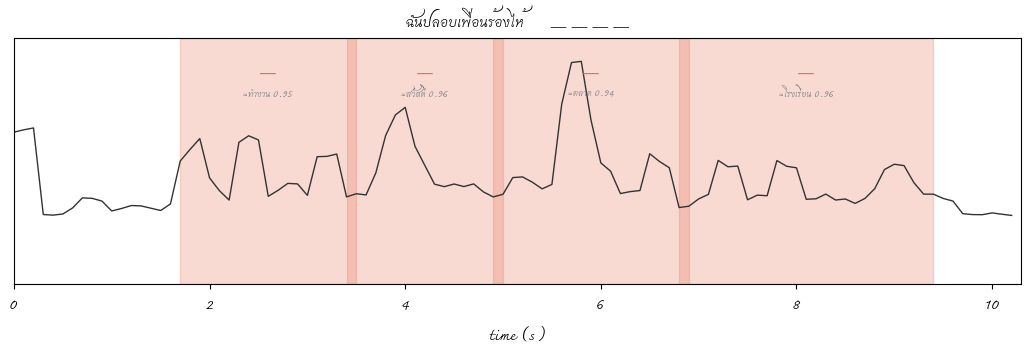

[v1 legacy] ไปทานข้าวด้วยกันมั้ย: words=[]  all CTC tokens=[]
quality: frames=67 pose=1.00 face=1.00 LH=1.00 RH=0.94 shoulderW=0.22
  ✓ input OK

=== ไปทานข้าวด้วยกันมั้ย ===
  SIGNS : _ _ _ _
    [0]  0.00- 1.92s  _        unknown  src=none   conf=0.00 sim=0.95  nearest=[('ทำงาน', 0.955), ('ตลาด', 0.936)]
    [1]  1.92- 3.92s  _        unknown  src=none   conf=0.00 sim=0.94  nearest=[('ทำงาน', 0.944), ('ตลาด', 0.93)]
    [2]  3.92- 5.72s  _        unknown  src=none   conf=0.00 sim=0.94  nearest=[('บ้าน', 0.941), ('กิน', 0.941)]
    [3]  5.72- 6.60s  _        unknown  src=none   conf=0.00 sim=0.93  nearest=[('ที่ไหน', 0.927), ('ทำงาน', 0.927)]
  FACE  : eyebrows raised (question-like / emphasis)
  THAI  : ___ ___ ___ ___ (none)
  file-name annotation: ไปทานข้าวด้วยกันมั้ย | known in name: ['ไป', 'ด้วยกัน', 'ข้าว'] | hints: {}
  memory: stored 4 segments | latency: {'1_mediapipe_s': 0.01, '2_extract_s': 0.03, '3_llm_s': 0.0, '4_tts_s': 0.0, 'total_s': 0.04}
  WER=0.600 known-recall=0.00

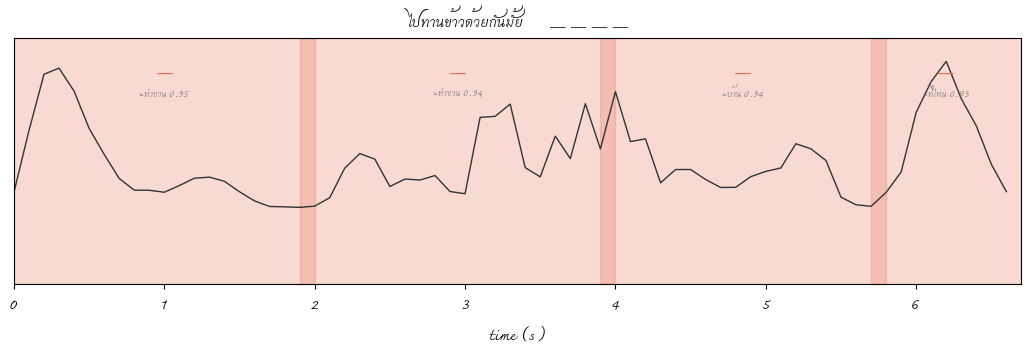

In [14]:
# --- v1 behaviour (เดิม): greedy CTC + threshold → ได้เฉพาะคำใน vocab, คำที่ไม่รู้ถูก "ทิ้งเงียบ ๆ" หรือ force เป็นคำใกล้เคียง
@torch.no_grad()
def legacy_extract(model, feat, min_conf=cfg.MIN_TOKEN_CONF):
    x = to_dev(pad_feats([feat])); o = model.forward_batch(x); toks = ctc_decode_with_confidence(o["logits_ctc"], [len(feat["hand"])])[0]
    return [CLASS2WORD[SIGN_CLASSES[t["cls"]]] for t in toks if t["conf"] >= min_conf], [(CLASS2WORD[SIGN_CLASSES[t["cls"]]], round(t["conf"], 2)) for t in toks]

memory = SignMemory()                      # memory/ (qdrant local) — สะสมข้ามการรัน
print("memory backend:", memory.backend, "| segments stored so far:", memory.count())
pipe = SLMPipeline(model=model_v2, protos=protos["v2"], memory=memory, extractor=extractor)

results = {}
for v in VIDEOS:
    display(Video(str(v), width=320))
    feat = make_features(load_landmarks(extract_cached(extractor, v)))
    w1, toks1 = legacy_extract(model_v1, feat); print(f"[v1 legacy] {v.stem}: words={w1}  all CTC tokens={toks1}")
    results[v.stem] = pipe.run(v, expected_words=EXPECTED.get(v.stem), speak=not FAST)
    plot_timeline(results[v.stem]["_analysis"], f"{v.stem}  →  {' '.join(results[v.stem]['words'])}"); plt.show()
    if results[v.stem]["wav"]: display(Audio(results[v.stem]["wav"]))

In [15]:
summary_videos = pd.DataFrame([dict(clip=k, v1_legacy=" ".join(legacy_extract(model_v1, make_features(load_landmarks(extract_cached(extractor, cfg.DATA_TEST_DIR / f"{k}.mp4"))))[0]) or "(nothing)",
                                    v2_words=" ".join(r["words"]), expected=" ".join(EXPECTED.get(k, [])), n_unknown=r["n_unknown"], known_recall=r.get("known_recall"), wer=r.get("wer"),
                                    thai=r["thai"], llm=r["llm"], memory_stored=r["memory_stored"]) for k, r in results.items()])
display(summary_videos); summary_videos.to_csv(cfg.OUT_DIR / "data_test_results.csv", index=False)

,clip,v1_legacy,v2_words,expected,n_unknown,known_recall,wer,thai,llm,memory_stored
0,ฉันปลอบเพื่อนร้องไห้,(nothing),_ _ _ _,ฉัน _ _ _,4,0.0,0.25,___ ___ ___ ___,none,4
1,ไปทานข้าวด้วยกันมั้ย,(nothing),_ _ _ _,ไป _ ข้าว ด้วยกัน _,4,0.0,0.60,___ ___ ___ ___,none,4


## 10. Memory (Qdrant local) — ดูสิ่งที่ถูกเก็บ / retrieve / ไฟล์ที่สร้าง

ทุก segment (known + unknown) ถูกเก็บพร้อม embedding 128-d และ metadata: `clip, slot_idx, start/end frame, t_start/t_end ms, word/status/source, conf, sim, nearest_known, candidate_sentence (ชื่อไฟล์), known_hits_in_name, synonym_hints, label`

In [16]:
tbl = memory.table(); display(tbl)
print("ไฟล์ที่สร้าง:"); [print("  ", p.relative_to(ROOT), f"({p.stat().st_size/1024:.1f} KB)") for p in sorted(cfg.MEMORY_DIR.rglob("*")) if p.is_file()]
# retrieve: segment ที่ใกล้ที่สุดของ unknown slot แรก (ข้ามคลิปตัวเอง)
unk = [s for r in results.values() for s in r["_analysis"]["slots"] if s["status"] == "unknown"]
if unk:
    q = unk[0]; print(f"\nquery: {q['clip']} slot {q['idx']} ({q['t_start_ms']/1000:.1f}-{q['t_end_ms']/1000:.1f}s) nearest known={q['nearest'][:2]}")
    for h in memory.retrieve(q["emb"], k=5): print(f"   score={h['score']:.3f}  {h['clip']} slot{h['slot_idx']} [{h['status']}] word={h['word']} label={h['label']}  name→{h['candidate_sentence']}")
# real-unknown segments จากคลิปจริง → เพิ่มเข้า open-set eval (v2)
if unk:
    ks, _ = known_unknown_scores(model_v2, protos["v2"], iso["test"], [])
    real_us = np.array([s["sim"] for s in unk]); r = openset_auroc(ks, real_us)
    print(f"\nopen-set v2 (known=isolated-test vs real unknown segments n={len(real_us)}): AUROC={r['auroc']:.3f} TNR@95TPR={r['tnr_at_95tpr']:.3f}")
    openset_df.loc[len(openset_df)] = dict(model="v2 (real unknown segs)", **{k: round(v, 4) for k, v in r.items()}, known_mean=round(ks.mean(), 4), unknown_mean=round(real_us.mean(), 4))

,clip,slot_idx,start_frame,end_frame,t_start_ms,t_end_ms,word,status,source,conf,sim,label,candidate_sentence,known_hits_in_name,created_at
0,ฉันปลอบเพื่อนร้องไห้,0,17,35,1700.0,3400.0,_,unknown,none,0.0,0.9528,None,ฉันปลอบเพื่อนร้องไห้,[ฉัน],2026-09-05T03:10:25
1,ฉันปลอบเพื่อนร้องไห้,1,34,50,3400.0,4900.0,_,unknown,none,0.0,0.9558,None,ฉันปลอบเพื่อนร้องไห้,[ฉัน],2026-09-05T03:10:25
2,ฉันปลอบเพื่อนร้องไห้,2,49,69,4900.0,6800.0,_,unknown,none,0.0,0.9422,None,ฉันปลอบเพื่อนร้องไห้,[ฉัน],2026-09-05T03:10:25
3,ฉันปลอบเพื่อนร้องไห้,3,68,94,6800.0,9300.0,_,unknown,none,0.0,0.9566,None,ฉันปลอบเพื่อนร้องไห้,[ฉัน],2026-09-05T03:10:25
4,ไปทานข้าวด้วยกันมั้ย,0,0,20,0.0,1920.0,_,unknown,none,0.0,0.9548,None,ไปทานข้าวด้วยกันมั้ย,"[ไป, ด้วยกัน, ข้าว]",2026-09-05T03:10:25
5,ไปทานข้าวด้วยกันมั้ย,1,19,40,1920.0,3920.0,_,unknown,none,0.0,0.9442,None,ไปทานข้าวด้วยกันมั้ย,"[ไป, ด้วยกัน, ข้าว]",2026-09-05T03:10:25
6,ไปทานข้าวด้วยกันมั้ย,2,39,58,3920.0,5720.0,_,unknown,none,0.0,0.9406,None,ไปทานข้าวด้วยกันมั้ย,"[ไป, ด้วยกัน, ข้าว]",2026-09-05T03:10:25
7,ไปทานข้าวด้วยกันมั้ย,3,57,67,5720.0,6600.0,_,unknown,none,0.0,0.9268,None,ไปทานข้าวด้วยกันมั้ย,"[ไป, ด้วยกัน, ข้าว]",2026-09-05T03:10:25


ไฟล์ที่สร้าง:
   memory\embeddings\ฉันปลอบเพื่อนร้องไห้.npz (12.7 KB)
   memory\embeddings\ไปทานข้าวด้วยกันมั้ย.npz (12.9 KB)
   memory\memory_np.json (28.8 KB)
   memory\segments.jsonl (6.6 KB)

query: ฉันปลอบเพื่อนร้องไห้ slot 0 (1.7-3.4s) nearest known=[('ทำงาน', 0.953), ('วันนี้', 0.95)]
   score=1.000  ฉันปลอบเพื่อนร้องไห้ slot0 [unknown] word=_ label=None  name→ฉันปลอบเพื่อนร้องไห้
   score=0.973  ฉันปลอบเพื่อนร้องไห้ slot3 [unknown] word=_ label=None  name→ฉันปลอบเพื่อนร้องไห้
   score=0.955  ไปทานข้าวด้วยกันมั้ย slot1 [unknown] word=_ label=None  name→ไปทานข้าวด้วยกันมั้ย
   score=0.954  ฉันปลอบเพื่อนร้องไห้ slot1 [unknown] word=_ label=None  name→ฉันปลอบเพื่อนร้องไห้
   score=0.945  ไปทานข้าวด้วยกันมั้ย slot0 [unknown] word=_ label=None  name→ไปทานข้าวด้วยกันมั้ย

open-set v2 (known=isolated-test vs real unknown segments n=8): AUROC=0.744 TNR@95TPR=0.000


## 11. Annotate → เรียนรู้คำใหม่โดยไม่ retrain (demo บน memory แยก `memory/_demo`)

flow จริง: ดู `memory.table()` / timeline → ระบุว่า slot ไหนคือคำอะไร → `memory.annotate(clip, {slot_idx: word})` → ครั้งหน้า `analyze_clip` เจอ embedding ใกล้ learned prototype (cos ≥ `MEMORY_SIM_THRESHOLD`) → คืนคำนั้น (status = `learned`)
*(demo นี้ map ตามลำดับ token ในชื่อไฟล์ — ของจริงต้องดูวิดีโอประกอบ)*

In [17]:
import shutil
demo_root = cfg.MEMORY_DIR / "_demo"; shutil.rmtree(demo_root, ignore_errors=True)
mem_demo = SignMemory(root=demo_root); pipe_demo = SLMPipeline(model=model_v2, protos=protos["v2"], memory=mem_demo, extractor=extractor)
clip = "ไปทานข้าวด้วยกันมั้ย"
r0 = pipe_demo.run(cfg.DATA_TEST_DIR / f"{clip}.mp4", translate=False, speak=False, show=False)
slots0 = [s for s in r0["slots"] if s["status"] != "null"]; print("before annotate:", [s["word"] for s in slots0])
unk_tokens = [t for t in r0["filename_annotation"]["tokens"] if t not in KNOWN_WORDS] or ["?"]       # คำในชื่อไฟล์ที่ไม่อยู่ใน vocab เช่น ['ทานข้าว','มั้ย']
labels, j = {}, 0
for s in slots0:
    if s["status"] in ("known", "learned"): labels[s["idx"]] = s["word"]
    else: labels[s["idx"]] = unk_tokens[min(j, len(unk_tokens) - 1)]; j += 1                              # demo mapping ตามลำดับ
print("annotate:", labels, "→", mem_demo.annotate(clip, labels, note="demo: mapped from file name"), "segments")
print("learned prototypes:", {k: v["n"] for k, v in mem_demo.learned_prototypes().items()})
r1 = pipe_demo.run(cfg.DATA_TEST_DIR / f"{clip}.mp4", translate=True, speak=False, show=False, save_memory=False)
print("after  annotate:", r1["words"], "→ THAI:", r1["thai"], f"({r1['llm']})")
print("   status/source:", [(s["word"], s["status"], s["source"], round(s["conf"], 2)) for s in r1["slots"] if s["status"] != "null"])
mem_demo.close()

qdrant unavailable → numpy fallback: ModuleNotFoundError No module named 'qdrant_client'
before annotate: ['_', '_', '_', '_']
annotate: {0: 'ทานข้าว', 1: 'มั้ย', 2: 'มั้ย', 3: 'มั้ย'} → 4 segments
learned prototypes: {'ทานข้าว': 1, 'มั้ย': 3}
after  annotate: ['ทานข้าว', 'มั้ย', 'มั้ย', 'มั้ย'] → THAI: ทานข้าวไหม? (gpt-5.6)
   status/source: [('ทานข้าว', 'learned', 'memory', 1.0), ('มั้ย', 'learned', 'memory', 1.0), ('มั้ย', 'learned', 'memory', 0.99), ('มั้ย', 'learned', 'memory', 0.99)]


## 12. Overlay video (debug ว่า segment/คำ ตรงกับท่าจริงไหม) + TTS

In [18]:
from slm_labs.tts import tts, speakable
k0 = VIDEOS[0].stem
ov = render_overlay_video(VIDEOS[0], results[k0]["_analysis"], cfg.OUT_DIR / "inference" / f"{k0}_overlay.mp4"); print("overlay →", ov); display(Video(str(ov), width=320))
thai0 = results[k0]["thai"]; print("THAI:", thai0, "| speak:", repr(speakable(thai0)))
if not FAST and thai0:
    w = tts(thai0, cfg.OUT_DIR / "inference" / f"{k0}_tts2.wav")
    if w: display(Audio(str(w)))

overlay → D:\SLM-labs\SLM-Labs\outputs\inference\ฉันปลอบเพื่อนร้องไห้_overlay.mp4


THAI: ___ ___ ___ ___ | speak: ''


## 13. Translation (LLM) eval บน dataset test — oracle glosses vs end-to-end (v1 / v2)
reference = rule-based ของ gloss จริง (proxy — ใส่ human reference ใน `REFERENCE_OVERRIDES` เมื่อมี) ; จำกัด `N_LLM_EVAL` ประโยคเพื่อเวลา/ค่าใช้จ่าย

In [19]:
from slm_labs.llm import llm_translate, rule_gloss_to_thai, face_cue
from slm_labs.metrics import bleu_chrf
REFERENCE_OVERRIDES = {}
N_LLM_EVAL = 3 if FAST else 12
idx = list(range(min(N_LLM_EVAL, len(sent["test"]))))
refs = [REFERENCE_OVERRIDES.get(" ".join(resB2["refs"][i]), rule_gloss_to_thai(resB2["refs"][i])) for i in idx]
cues = [face_cue(sent["test"][i]["feat"]["face"])["text"] for i in idx]
hyp_or = [llm_translate(resB2["refs"][i], c)[0] for i, c in zip(idx, cues)]
hyp_v1 = [llm_translate(resB1["hyps"][i], c)[0] for i, c in zip(idx, cues)]
hyp_v2 = [llm_translate(resB2["hyps"][i], c)[0] for i, c in zip(idx, cues)]
tr = {n: bleu_chrf(refs, h) for n, h in [("oracle", hyp_or), ("e2e v1", hyp_v1), ("e2e v2", hyp_v2)]}
trans_df = pd.DataFrame({k: dict(BLEU_char=v[0], chrF=v[1]) for k, v in tr.items()}).T.round(2); display(trans_df)
display(pd.DataFrame({"ref": refs, "oracle": hyp_or, "e2e v1": hyp_v1, "e2e v2": hyp_v2}).head(6))

,BLEU_char,chrF
oracle,88.83,91.35
e2e v1,0.00,0.00
e2e v2,0.00,0.00


,ref,oracle,e2e v1,e2e v2
0,ฉันชอบเที่ยวกรุงเทพ,ฉันชอบเที่ยวที่กรุงเทพฯ,,
1,น้องชอบเที่ยวกรุงเทพ,น้องชอบไปเที่ยวกรุงเทพ,,
2,พี่ชอบเที่ยวกรุงเทพ,พี่ชอบไปเที่ยวกรุงเทพฯ,,
3,ยายชอบเที่ยวกรุงเทพ,ยายชอบไปเที่ยวกรุงเทพฯ,,
4,แฟนชอบเที่ยวกรุงเทพ,แฟนชอบเที่ยวกรุงเทพฯ,,
5,แม่ชอบเที่ยวกรุงเทพ,แม่ชอบเที่ยวกรุงเทพฯ,,


## 14. Metrics summary — v1 (เดิม) vs v2 (ใหม่)

In [20]:
def row(stage, metric, v1, v2): return dict(stage=stage, metric=metric, v1=v1, v2=v2)
S = [row("Sign recognition (isolated test)", "accuracy", resA1["acc"], resA2["acc"]),
     row("Sign recognition (isolated test)", "macro-F1", resA1["macro_f1"], resA2["macro_f1"]),
     row("Sign sequence (sentence test)", "WER", resB1["wer"], resB2["wer"]),
     row("Sign sequence (sentence test)", "CER", resB1["cer"], resB2["cer"]),
     row("Sign sequence (sentence test)", "sentence acc", resB1["sent_acc"], resB2["sent_acc"]),
     row("Face contribution", "ΔWER (no-face − face)", resB1_nof["wer"] - resB1["wer"], resB2_nof["wer"] - resB2["wer"])]
for st in shift.index: S.append(row("Domain-shift robustness", f"acc @ strength {st}", shift.loc[st, "v1"], shift.loc[st, "v2 (SSL)"]))
S.append(row("Embedding quality", "prototype-NN acc (val)", protos["v1"].stats["val_nn_acc"], protos["v2"].stats["val_nn_acc"]))
S.append(row("Open-set (known vs reversed)", "AUROC", openset_df.iloc[0]["auroc"], openset_df.iloc[1]["auroc"]))
S.append(row("Open-set (known vs reversed)", "TNR@95%TPR", openset_df.iloc[0]["tnr_at_95tpr"], openset_df.iloc[1]["tnr_at_95tpr"]))
S.append(row("Segment count (sentence test)", "MAE motion-only → model-assisted", seg_df.iloc[1]["mae"], seg_df.iloc[2]["mae"]))
S.append(row("Translation (LLM)", "chrF e2e", trans_df.loc["e2e v1", "chrF"], trans_df.loc["e2e v2", "chrF"]))
for k, r in results.items():
    S.append(row(f"Real video: {k}", "extracted", summary_videos.set_index("clip").loc[k, "v1_legacy"], " ".join(r["words"])))
    S.append(row(f"Real video: {k}", "known-recall / #unknown stored", "n/a", f"{r.get('known_recall', float('nan')):.2f} / {r['n_unknown']}"))
summary = pd.DataFrame(S); summary["v1"] = summary["v1"].map(lambda x: round(x, 4) if isinstance(x, float) else x); summary["v2"] = summary["v2"].map(lambda x: round(x, 4) if isinstance(x, float) else x)
display(summary); summary.to_csv(cfg.OUT_DIR / "metrics_summary_v2.csv", index=False)
json.dump(dict(summary=summary.to_dict("records"), shift=shift.reset_index().to_dict("records"), openset=openset_df.to_dict("records"), segcount=seg_df.to_dict("records"),
               translation=trans_df.reset_index().to_dict("records"), videos=summary_videos.to_dict("records"), fast=FAST, cfg=cfg.to_dict()),
          open(cfg.OUT_DIR / "summary_v2.json", "w", encoding="utf-8"), ensure_ascii=False, indent=1, default=str)
print("saved →", cfg.OUT_DIR / "metrics_summary_v2.csv", "|", cfg.OUT_DIR / "summary_v2.json")
memory.close()

,stage,metric,v1,v2
0,Sign recognition (isolated test),accuracy,0.9759,0.3373
1,Sign recognition (isolated test),macro-F1,0.9806,0.2518
2,Sign sequence (sentence test),WER,1.0,1.0
3,Sign sequence (sentence test),CER,1.0,1.0
4,Sign sequence (sentence test),sentence acc,0.0,0.0
5,Face contribution,ΔWER (no-face − face),-0.0186,0.0
6,Domain-shift robustness,acc @ strength 0.0,0.9759,0.3373
7,Domain-shift robustness,acc @ strength 1.0,0.9639,0.3253
8,Domain-shift robustness,acc @ strength 1.6,0.9639,0.4096
9,Domain-shift robustness,acc @ strength 2.2,0.9157,0.3976


saved → D:\SLM-labs\SLM-Labs\outputs\metrics_summary_v2.csv | D:\SLM-labs\SLM-Labs\outputs\summary_v2.json


### Next steps
- **annotate จริง**: ดู `memory.table()` + timeline/overlay → `memory.annotate("<clip>", {slot_idx: "คำ"})` → คำใหม่ใช้ได้ทันที (kNN กับ learned prototype) ; เมื่อสะสมพอ → เพิ่ม class แล้ว fine-tune (Stage A) ด้วย segment เหล่านั้นเป็น isolated samples
- **open-set ที่แท้จริง**: train แบบ hold-out classes (เช่น ตัด 8 คำออกจาก train) เพื่อวัด AUROC กับ "คำจริงที่ไม่เคยเห็น" แทน pseudo-unknown
- SSL: เพิ่ม epoch / ใช้ expert augmented 32k คลิปเป็น unlabeled pool (SSL ไม่ต้องการ label) / GPU
- segmentation: เรียน boundary detector จาก CTC alignment (แทน heuristic energy-valley) ; ใช้ face/mouth cue ช่วยตัดคำ
- LLM: ใส่ human reference ให้ครบ 76 pattern ; ประเมิน semantic accuracy โดยคน